### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Short / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: E/P and P/B
10. Universe size over time
11. Portfolio breadth over time
12. Long vs short composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/aqr_full_price_available_universe_modular"
STRATEGY_NAME = "AQR Strategy"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (310, 4)
asset_returns: (214044, 11)
weights_at_E: (214044, 22)
signals_at_T: (535859, 18)
portfolio_membership_at_T: (214044, 21)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if len(monthly_returns) == 0 or monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
monthly_side = (
    asset_returns.groupby(
        ["signal_date", "execution_date", "next_execution_date", "side"],
        as_index=False
    )["weighted_return"]
    .sum()
)

monthly_side_pivot = (
    monthly_side.pivot(
        index=["signal_date", "execution_date", "next_execution_date"],
        columns="side",
        values="weighted_return"
    )
    .reset_index()
)

monthly_side_pivot.columns.name = None

if "long" not in monthly_side_pivot.columns:
    monthly_side_pivot["long"] = 0.0
if "short" not in monthly_side_pivot.columns:
    monthly_side_pivot["short"] = 0.0

monthly_side_pivot["net"] = monthly_side_pivot["long"] + monthly_side_pivot["short"]
monthly_side_pivot.head()

,signal_date,execution_date,next_execution_date,long,short,net
0,2000-02-29,2000-03-01,2000-04-03,0.011283,-0.004544,0.006739
1,2000-03-31,2000-04-03,2000-05-01,0.004794,0.014092,0.018885
2,2000-04-28,2000-05-01,2000-06-01,0.004786,0.039137,0.043922
3,2000-05-31,2000-06-01,2000-07-03,-0.014998,-0.061693,-0.076691
4,2000-06-30,2000-07-03,2000-08-01,-0.005604,0.017849,0.012245


In [8]:
check = portfolio_returns.merge(
    monthly_side_pivot[["signal_date", "execution_date", "next_execution_date", "net"]],
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["net"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 1.687538997430238e-14
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_leg": performance_summary(monthly_side_pivot["long"]),
    "short_leg": performance_summary(monthly_side_pivot["short"]),
    "net_portfolio": performance_summary(monthly_side_pivot["net"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_leg,0.005130,0.025952,0.684767,0.616129,-0.299005
short_leg,-0.003692,0.039503,-0.323782,0.445161,-0.837064
net_portfolio,0.001438,0.024408,0.204048,0.551613,-0.430039


### 5. Cumulative performance plot: Long / Short / Net

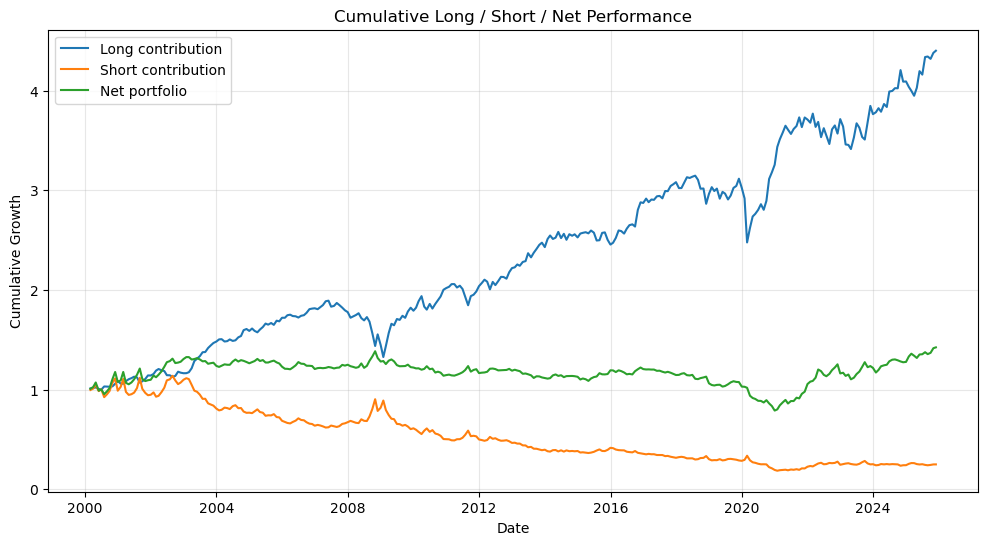

In [10]:
plot_df = monthly_side_pivot.sort_values("signal_date").copy()
plot_df["cum_long"] = (1 + plot_df["long"]).cumprod()
plot_df["cum_short"] = (1 + plot_df["short"]).cumprod()
plot_df["cum_net"] = (1 + plot_df["net"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_long"], label="Long contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_short"], label="Short contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_net"], label="Net portfolio")
plt.title("Cumulative Long / Short / Net Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

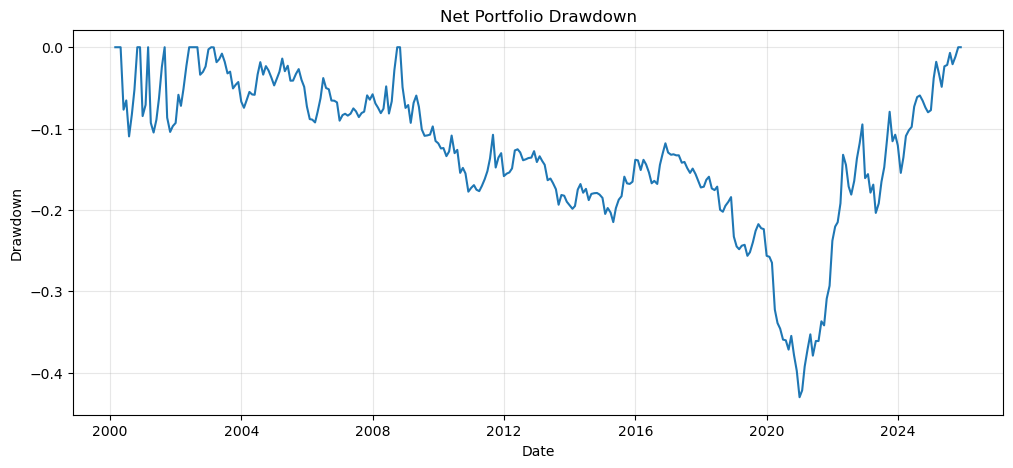

In [11]:
drawdown_df = plot_df[["signal_date", "net"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["net"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Net Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

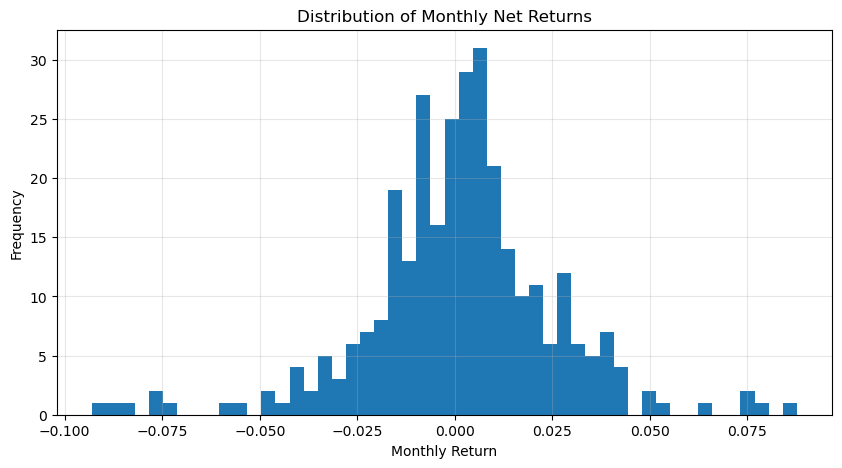

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(monthly_side_pivot["net"], bins=50)
plt.title("Distribution of Monthly Net Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
monthly_side_pivot[["long", "short", "net"]].describe()

,long,short,net
count,310.000000,310.000000,310.000000
mean,0.005130,-0.003692,0.001438
std,0.025952,0.039503,0.024408
min,-0.151209,-0.136817,-0.092944
25%,-0.009028,-0.025353,-0.009938
50%,0.006446,-0.004358,0.001718
75%,0.019784,0.017110,0.014135
max,0.091360,0.141422,0.087690


In [14]:
print("Long-short monthly return correlation:", monthly_side_pivot["long"].corr(monthly_side_pivot["short"]))

Long-short monthly return correlation: -0.799010655758499


### 9. Signal diagnostics: E/P and P/B

In [15]:
signal_cols_to_check = [
    c for c in [
        "value_signal",
        "quality_signal",
        "momentum_signal",
        "book_equity",
        "market_cap",
        "revenue",
        "operatingIncome",
        "mom_1m"
    ]
    if c in weights_at_E.columns
]

signal_cols_to_check

['value_signal',
 'quality_signal',
 'momentum_signal',
 'book_equity',
 'market_cap',
 'revenue',
 'operatingIncome',
 'mom_1m']

In [16]:
for col in signal_cols_to_check:
    print(f"\n=== {col} ===")
    display(weights_at_E[col].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


=== value_signal ===


count    2.140440e+05
mean     1.905567e+01
std      3.536352e+03
min      2.028149e-08
1%       4.449706e-03
5%       3.546473e-02
50%      4.892532e-01
95%      1.664065e+00
99%      9.697153e+00
max      9.707549e+05
Name: value_signal, dtype: float64


=== quality_signal ===


count    214044.000000
mean         -0.176302
std           3.932838
min        -220.967680
1%           -7.475823
5%           -1.479202
50%           0.103822
95%           0.506249
99%           0.873347
max         725.171753
Name: quality_signal, dtype: float64


=== momentum_signal ===


...

count    2.140440e+05
mean     2.205137e+10
std      4.399765e+11
min      1.000500e+06
1%       1.404000e+06
5%       3.689150e+06
50%      1.411770e+08
95%      6.608000e+09
99%      3.893282e+10
max      2.806365e+13
Name: revenue, dtype: float64


=== operatingIncome ===


count    2.140440e+05
mean     4.030310e+09
std      1.280014e+11
min     -1.271624e+13
1%      -2.996042e+08
5%      -4.474700e+07
50%      1.190700e+07
95%      1.073216e+09
99%      6.701000e+09
max      7.373152e+12
Name: operatingIncome, dtype: float64


=== mom_1m ===


count    214044.000000
mean          0.003289
std           0.207437
min          -4.406742
1%           -0.377817
5%           -0.225182
50%           0.002342
95%           0.221715
99%           0.441817
max          38.946521
Name: mom_1m, dtype: float64

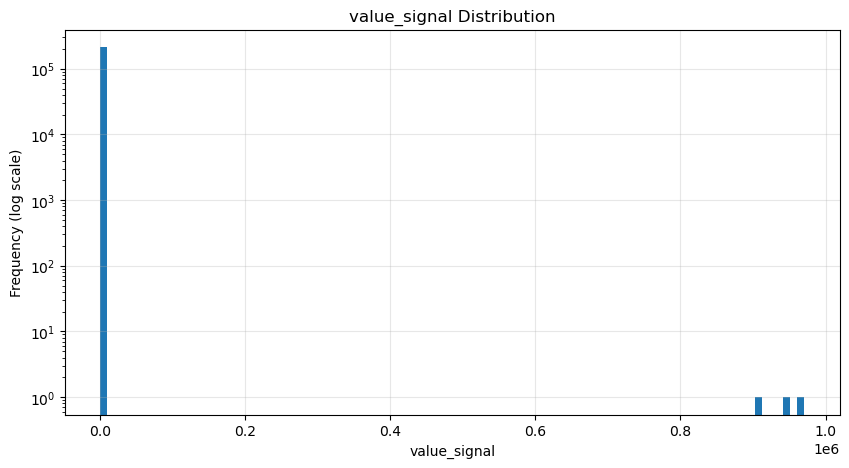

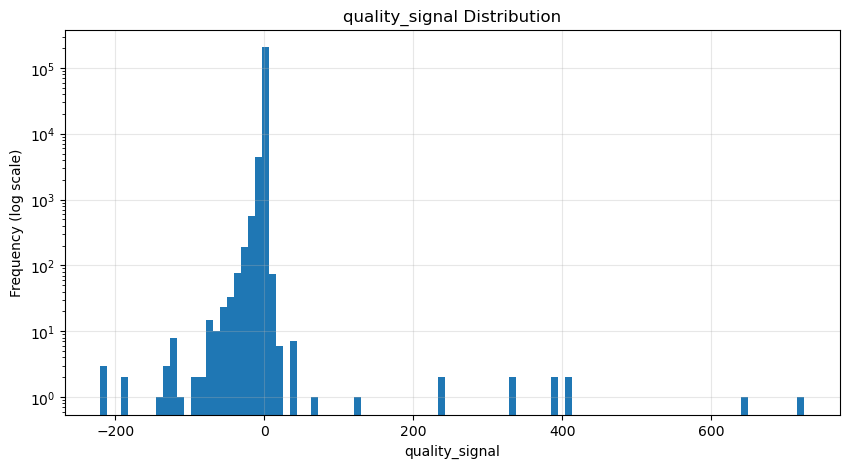

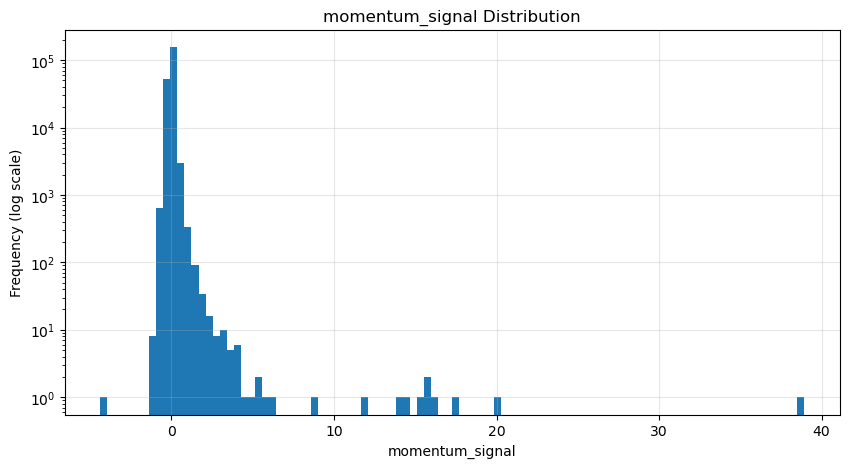

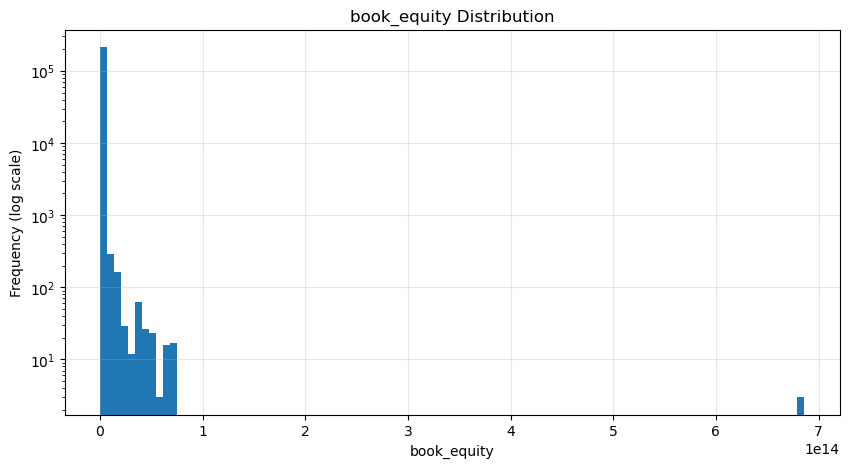

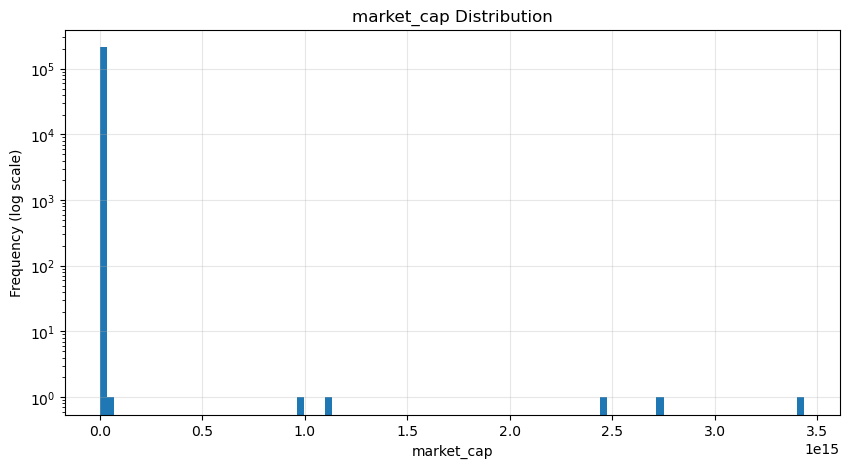

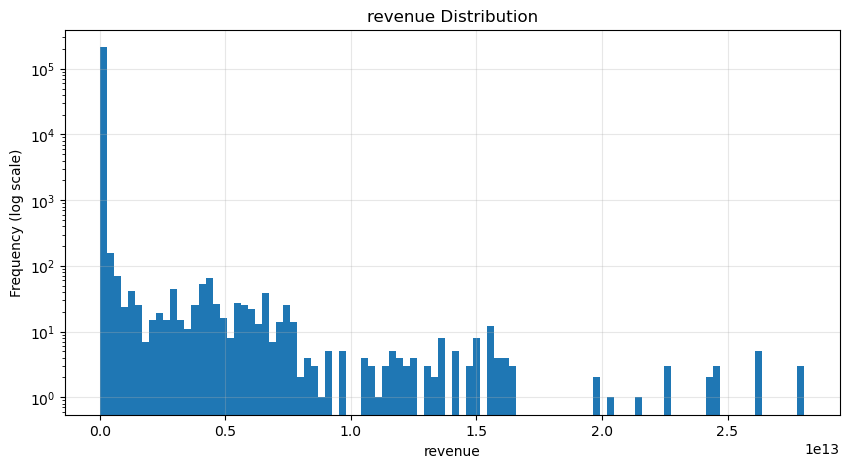

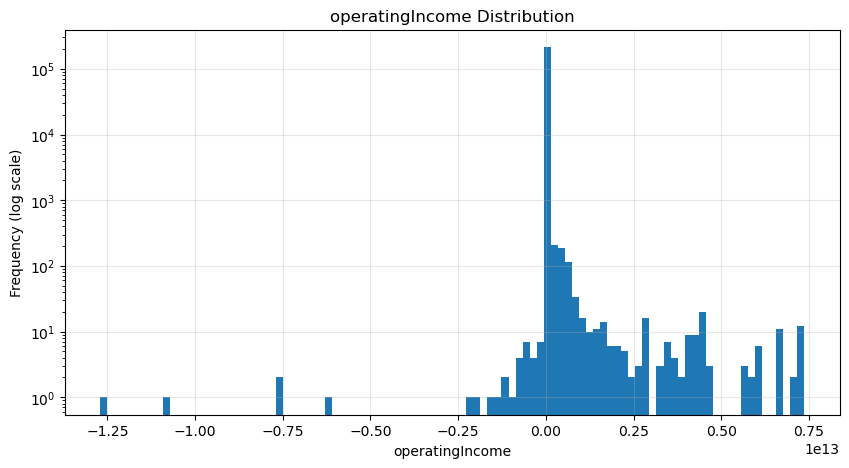

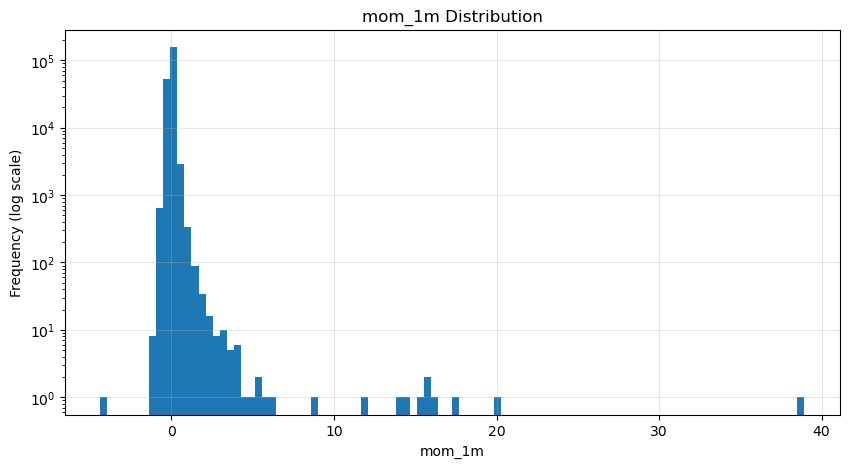

In [17]:
for col in signal_cols_to_check:
    plt.figure(figsize=(10, 5))
    plt.hist(weights_at_E[col].dropna(), bins=100)
    plt.yscale("log")
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, alpha=0.3)
    plt.show()

### 10. Universe size over time

In [18]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2000-02-29,713
1,2000-03-31,746
2,2000-04-28,753
3,2000-05-31,744
4,2000-06-30,750


In [19]:
universe_size["n_universe"].describe()

count     310.000000
mean     1728.577419
std       591.473383
min       713.000000
25%      1273.750000
50%      1620.000000
75%      2148.250000
max      2724.000000
Name: n_universe, dtype: float64

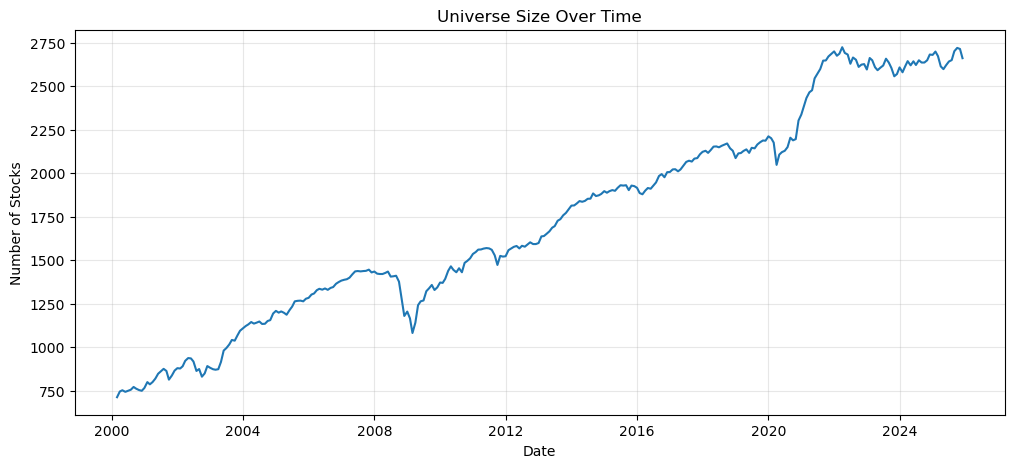

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [21]:
breadth = (
    asset_returns.groupby(["signal_date", "side"])["ticker"]
    .nunique()
    .reset_index()
)

breadth_pivot = breadth.pivot(index="signal_date", columns="side", values="ticker").reset_index()
breadth_pivot.columns.name = None

if "long" not in breadth_pivot.columns:
    breadth_pivot["long"] = np.nan
if "short" not in breadth_pivot.columns:
    breadth_pivot["short"] = np.nan

breadth_pivot.head()

,signal_date,long,short
0,2000-02-29,142,142
1,2000-03-31,149,149
2,2000-04-28,150,150
3,2000-05-31,148,148
4,2000-06-30,150,150


In [22]:
breadth_pivot[["long", "short"]].describe()

,long,short
count,310.000000,310.000000
mean,345.206452,345.258065
std,118.346958,118.278063
min,142.000000,142.000000
25%,254.250000,254.250000
50%,323.500000,323.500000
75%,429.000000,428.750000
max,544.000000,544.000000


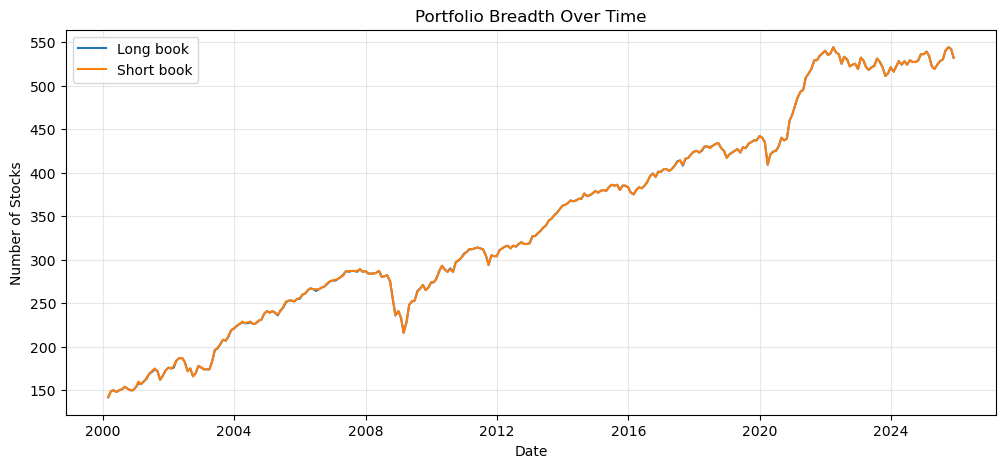

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(breadth_pivot["signal_date"], breadth_pivot["long"], label="Long book")
plt.plot(breadth_pivot["signal_date"], breadth_pivot["short"], label="Short book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long vs short composition

In [24]:
factor_cols = [
    c for c in [
        "market_cap",
        "book_equity",
        "revenue",
        "operatingIncome",
        "value_signal",
        "quality_signal",
        "momentum_signal",
        "mom_1m"
    ]
    if c in weights_at_E.columns
]

factor_cols

['market_cap',
 'book_equity',
 'revenue',
 'operatingIncome',
 'value_signal',
 'quality_signal',
 'momentum_signal',
 'mom_1m']

In [25]:
factor_summary = (
    weights_at_E.groupby("side")[factor_cols]
    .mean()
    .T
)

factor_summary

side,long,short
market_cap,9.862492e+09,1.240580e+11
book_equity,1.635622e+11,2.122287e+09
revenue,4.252298e+10,1.582820e+09
operatingIncome,8.155582e+09,-9.434610e+07
value_signal,3.773085e+01,3.832820e-01
quality_signal,3.181336e-01,-6.706644e-01
momentum_signal,7.929459e-02,-7.270498e-02
mom_1m,7.929459e-02,-7.270498e-02


In [26]:
factor_check = (
    weights_at_E.groupby(["signal_date", "side"])[factor_cols]
    .mean()
    .reset_index()
)

factor_check.head()

,signal_date,side,market_cap,book_equity,revenue,operatingIncome,value_signal,quality_signal,momentum_signal,mom_1m
0,2000-02-29,long,4.215086e+09,1.628171e+09,6.253217e+08,2.882171e+08,0.827056,0.309475,0.108305,0.108305
1,2000-02-29,short,1.964507e+10,2.918279e+09,2.554676e+09,1.904681e+08,0.262477,-0.249349,0.091829,0.091829
2,2000-03-31,long,6.157188e+09,2.516024e+09,1.298361e+09,4.474225e+08,0.812412,0.318747,0.177024,0.177024
3,2000-03-31,short,8.937070e+09,1.136373e+09,1.059866e+09,4.905016e+07,0.185419,-0.325688,-0.124530,-0.124530
4,2000-04-28,long,3.176756e+09,1.682949e+09,1.084167e+09,3.165193e+08,0.888541,0.274522,0.104297,0.104297


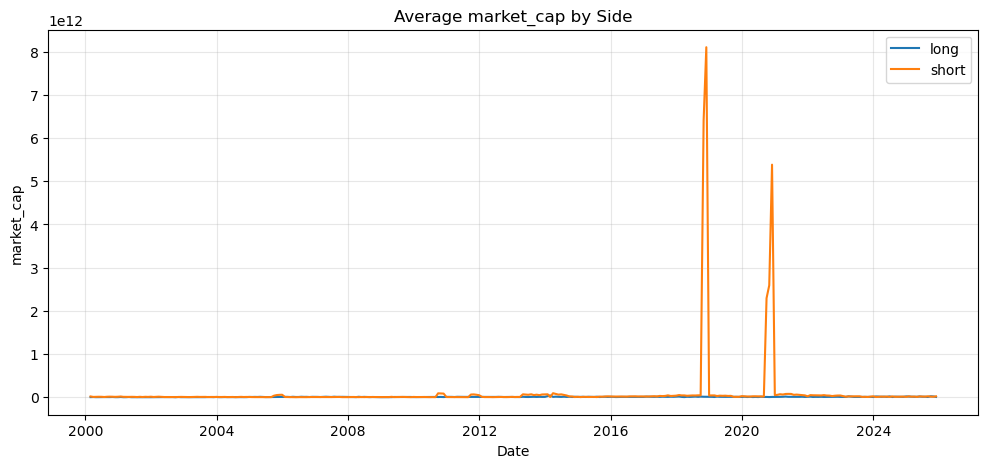

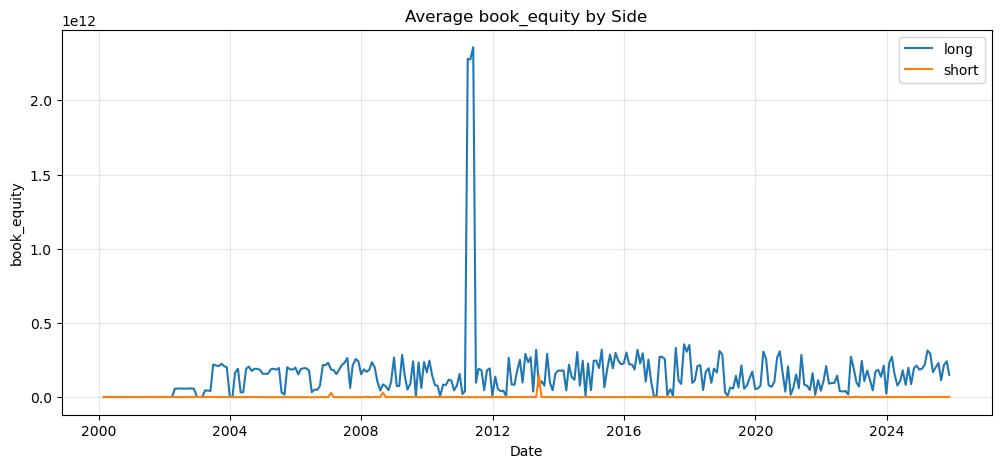

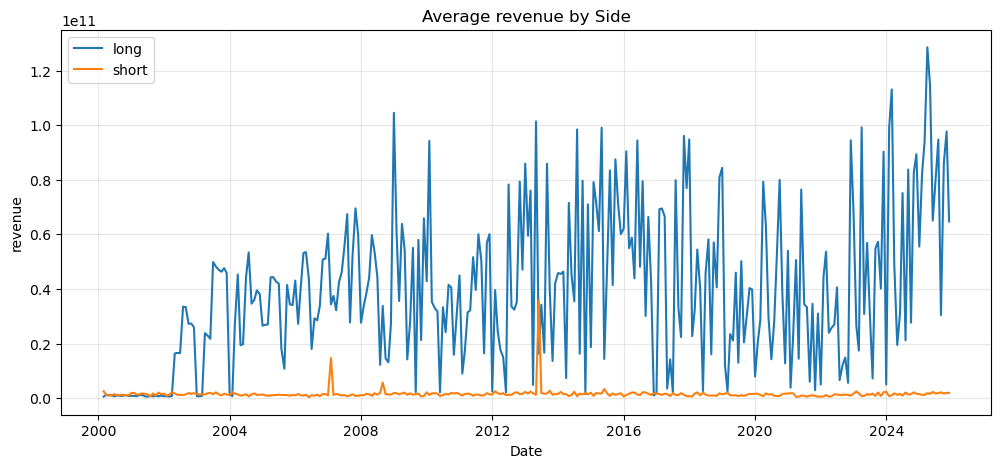

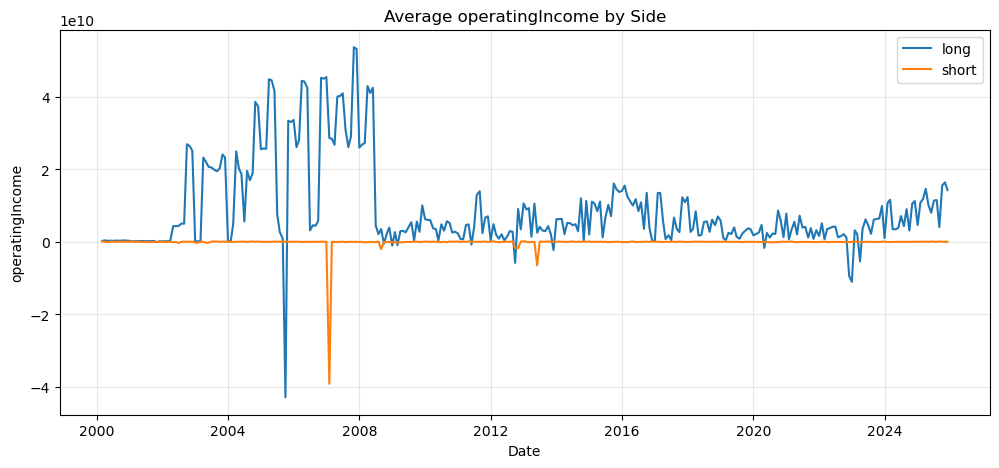

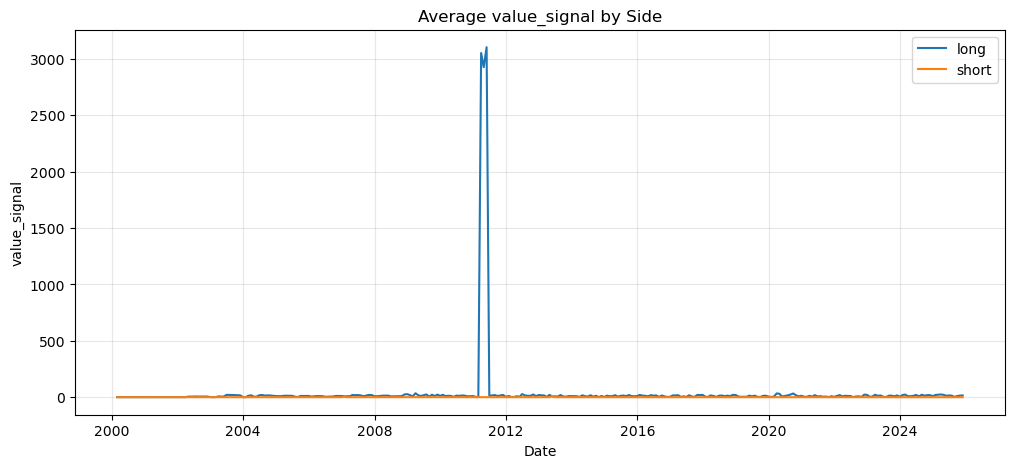

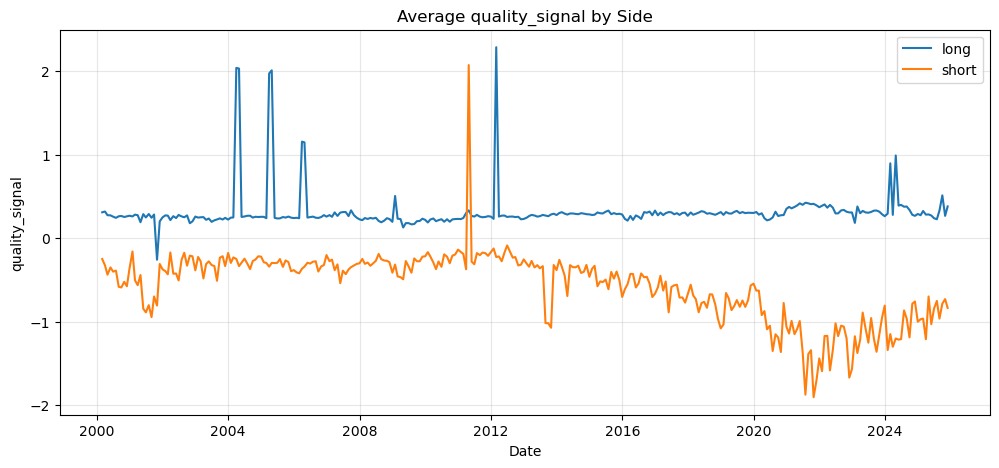

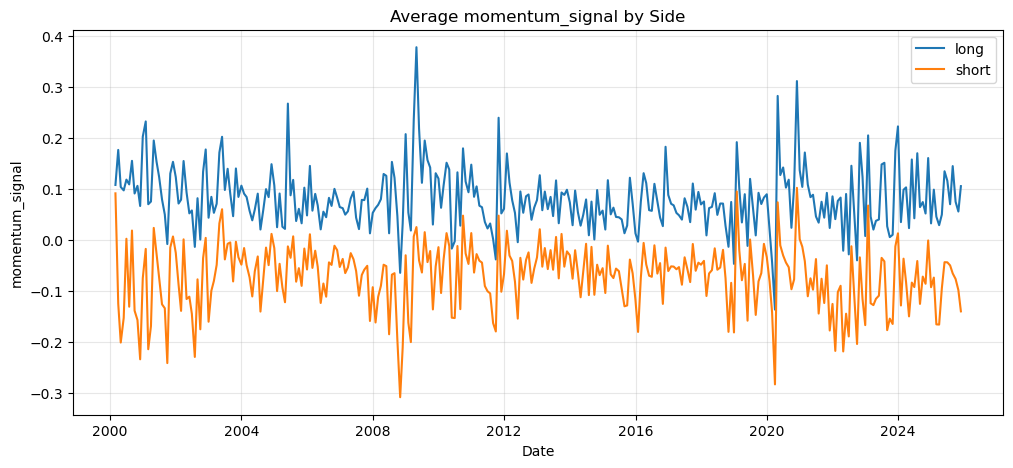

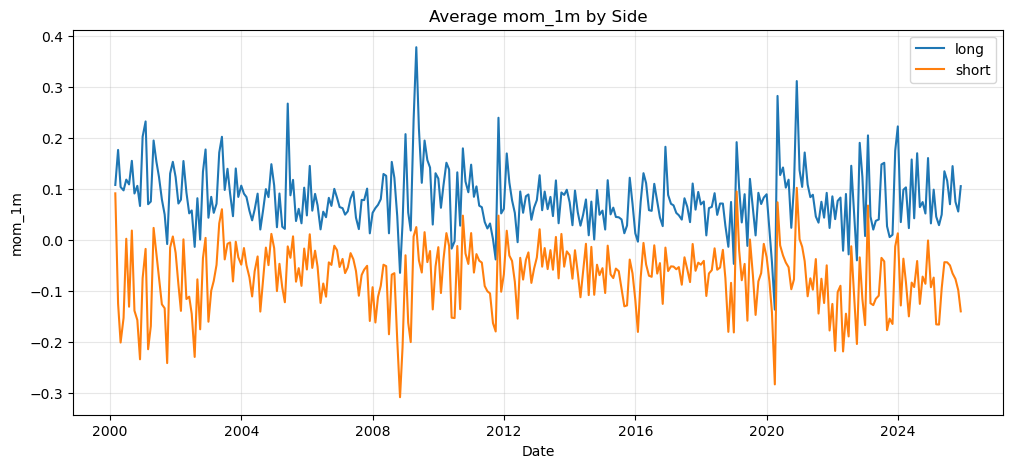

In [27]:
for col in factor_cols:
    plt.figure(figsize=(12, 5))
    for side in ["long", "short"]:
        tmp = factor_check[factor_check["side"] == side]
        if not tmp.empty:
            plt.plot(tmp["signal_date"], tmp[col], label=side)
    plt.title(f"Average {col} by Side")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 13. Benchmark comparison vs S&P 500

In [28]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])
sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [29]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [30]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(219, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2000-02-29,2000-03-01,2000-04-03,0.006739,-0.020108
1,2000-03-31,2000-04-03,2000-05-01,0.018885,0.096720
2,2000-05-31,2000-06-01,2000-07-03,-0.076691,-0.021915
3,2000-06-30,2000-07-03,2000-08-01,0.012245,0.023934
4,2000-07-31,2000-08-01,2000-09-01,-0.047261,-0.016341


In [31]:
merged["cum_aqr"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_aqr", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_aqr,cum_sp
0,2000-02-29,0.006739,-0.020108,1.006739,0.979892
1,2000-03-31,0.018885,0.096720,1.025752,1.074667
2,2000-05-31,-0.076691,-0.021915,0.947085,1.051116
3,2000-06-30,0.012245,0.023934,0.958683,1.076272
4,2000-07-31,-0.047261,-0.016341,0.913374,1.058685


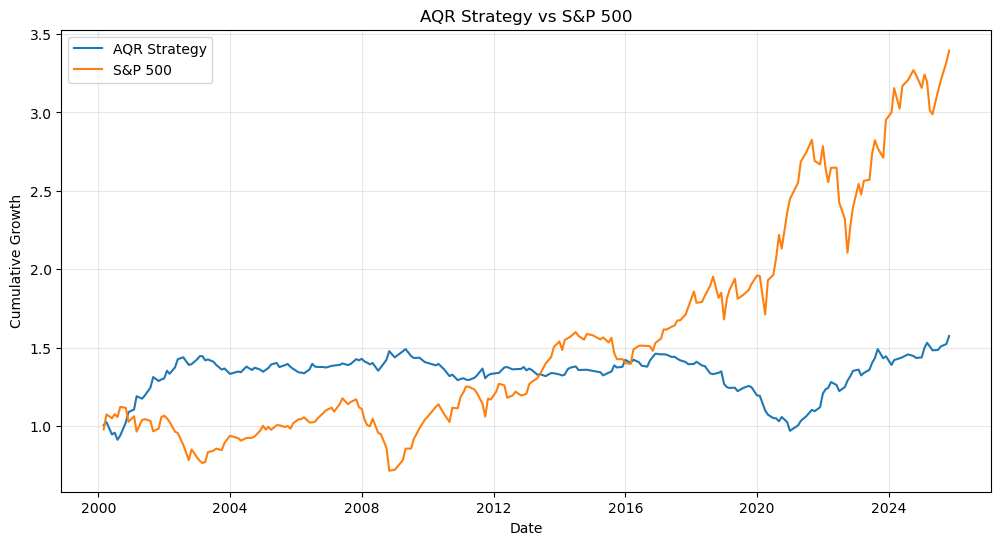

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_aqr"], label="AQR Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("AQR Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
print("AQR Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

AQR Sharpe: 0.3522892238585818
S&P 500 Sharpe: 0.5126480875005088


In [34]:
benchmark_summary = pd.DataFrame({
    "AQR Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
AQR Strategy,0.002338,0.022991,0.352289,0.561644,-0.349458
S&P 500,0.006593,0.044552,0.512648,0.607306,-0.391858


### 14. Turnover

In [35]:
membership_sets = (
    weights_at_E.groupby(["signal_date", "side"])["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values(["side", "signal_date"])
    .reset_index(drop=True)
)

membership_sets.head()

,signal_date,side,ticker_set
0,2000-02-29,long,"{PNW, BSF, COLM, FFKT, MCHP, HIG, MITK, POWL, ..."
1,2000-03-31,long,"{PNW, HIG, BSF, FFKT, AFL, CATY, GHC, NPK, IND..."
2,2000-04-28,long,"{PNW, BSF, HIG, CIX, FFKT, AFL, CATY, CBRL, QC..."
3,2000-05-31,long,"{PNW, BSF, CATY, QCRH, INDB, BMO, JOUT, APD, C..."
4,2000-06-30,long,"{PNW, BSF, CIX, FFKT, POWL, CATY, FUL, QCRH, B..."


In [36]:
turnover_records = []

for side in membership_sets["side"].dropna().unique():
    tmp = membership_sets[membership_sets["side"] == side].sort_values("signal_date").reset_index(drop=True)

    for i in range(1, len(tmp)):
        prev_set = tmp.loc[i - 1, "ticker_set"]
        curr_set = tmp.loc[i, "ticker_set"]

        entered = len(curr_set - prev_set)
        exited = len(prev_set - curr_set)
        union_n = len(curr_set | prev_set)
        prev_n = len(prev_set)

        turnover_records.append({
            "signal_date": tmp.loc[i, "signal_date"],
            "side": side,
            "entered": entered,
            "exited": exited,
            "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
            "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
        })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,side,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2000-03-31,long,98,91,1.330986,0.212500
1,2000-04-28,long,71,70,0.946309,0.359091
2,2000-05-31,long,73,75,0.986667,0.336323
3,2000-06-30,long,77,75,1.027027,0.324444
4,2000-07-31,long,89,88,1.180000,0.259414


In [37]:
turnover_df.groupby("side")[["turnover_rate_vs_prev", "jaccard_similarity"]].describe()

turnover_rate_vs_prev                                                    \
                      count      mean       std       min       25%       50%   
side                                                                            
long                  309.0  0.938317  0.153286  0.555766  0.830128  0.930902   
short                 309.0  0.976698  0.105284  0.550000  0.921671  0.982456   

                          jaccard_similarity                                \
            75%       max              count      mean       std       min   
side                                                                         
long   1.053512  1.351695              309.0  0.366037  0.070038  0.198492   
short  1.040000  1.213483              309.0  0.346489  0.047658  0.250883   

                                               
            25%       50%       75%       max  
side                                           
long   0.310954  0.365196  0.409091  0.565089  
short  0.315104  0.342308  0.369928  0.567055

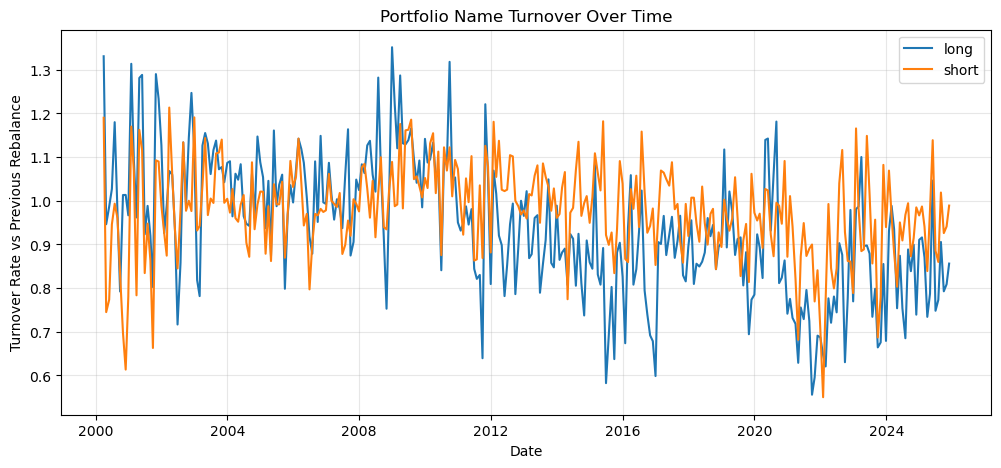

In [38]:
plt.figure(figsize=(12, 5))
for side in turnover_df["side"].dropna().unique():
    tmp = turnover_df[turnover_df["side"] == side]
    plt.plot(tmp["signal_date"], tmp["turnover_rate_vs_prev"], label=side)

plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [39]:
print("=== MODEL SUMMARY ===")
print(f"Long-leg Sharpe: {annualized_sharpe(monthly_side_pivot['long']):.4f}")
print(f"Short-leg Sharpe: {annualized_sharpe(monthly_side_pivot['short']):.4f}")
print(f"Net Sharpe: {annualized_sharpe(monthly_side_pivot['net']):.4f}")
print(f"Max drawdown: {max_drawdown(monthly_side_pivot['net']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth_pivot['long'].mean():.2f}")
print(f"Average short breadth: {breadth_pivot['short'].mean():.2f}")
print(f"Average long turnover: {turnover_df.loc[turnover_df['side']=='long', 'turnover_rate_vs_prev'].mean():.4f}")
print(f"Average short turnover: {turnover_df.loc[turnover_df['side']=='short', 'turnover_rate_vs_prev'].mean():.4f}")

=== MODEL SUMMARY ===
Long-leg Sharpe: 0.6848
Short-leg Sharpe: -0.3238
Net Sharpe: 0.2040
Max drawdown: -0.4300
Average universe size: 1728.58
Average long breadth: 345.21
Average short breadth: 345.26
Average long turnover: 0.9383
Average short turnover: 0.9767
